# 01 - Data Exploration

The project follows the following structure: 

1. Integrity checks
2. Understand variables
3. Univariate distributions
4. Correlations
5. Relationships / visualisations
6. Time patterns
7. Formulate statistical questions
8. Hypothesis tests
9. Confidence intervals
10. ANOVA + post-hoc analysis
11. SQL analysis
12. Final visualisation / dashboard

This notebook contains sections 1 through 6.

### Integrity checks

Before any analysis can begin, we must load the data, check for parsing errors, missing values, duplicate rows, unique values for categorical variables and the date range. Once these are addressed we will begin a univariate analysis. 



In [74]:
import pandas as pd

In [75]:
#Initial load + check parsing
data_days = pd.read_csv("../data/raw/day.csv")
data_days.head(5)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [76]:

# Info on shape of df, column names and variable types
#data_days.shape
#data_days.columns
#data_days.dtypes
data_days.info() #.info() shows the same details as the above functions


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [77]:
#Checking for NA/missing values
print("Missing values per column: \n", data_days.isna().sum(), "\n")

#checking duplicates
print("Duplicate rows: \n", data_days.duplicated().sum(), "\n")

#Selection of categorical, numerical/continuous variables (we're excluding dtday as it is a date variable)
categorical_var = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
numerical_var = data_days.columns[~data_days.columns.isin(categorical_var + ["instant","dteday"] )]

#Unique values and their count per categorical variable
for i in categorical_var:
    print("Unique values in ", i, ":", data_days[i].unique())
print("\nNumber of unique values per variable: \n", data_days[categorical_var].nunique())


Missing values per column: 
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64 

Duplicate rows: 
 0 

Unique values in  season : [1 2 3 4]
Unique values in  yr : [0 1]
Unique values in  mnth : [ 1  2  3  4  5  6  7  8  9 10 11 12]
Unique values in  holiday : [0 1]
Unique values in  weekday : [6 0 1 2 3 4 5]
Unique values in  workingday : [0 1]
Unique values in  weathersit : [2 1 3]

Number of unique values per variable: 
 season         4
yr             2
mnth          12
holiday        2
weekday        7
workingday     2
weathersit     3
dtype: int64


In [78]:
# Date range
data_days["dteday"] = pd.to_datetime(data_days["dteday"])
print("range of dates in df: ", (data_days["dteday"].max() - data_days["dteday"].min()).days)

range of dates in df:  730


### Univariate Analysis

In [79]:
data_days[numerical_var].describe()

,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Note that most variables seem centered, except for casual. Plotting the data in a histogram can visualize the skew.

Text(0, 0.5, 'Frequency')

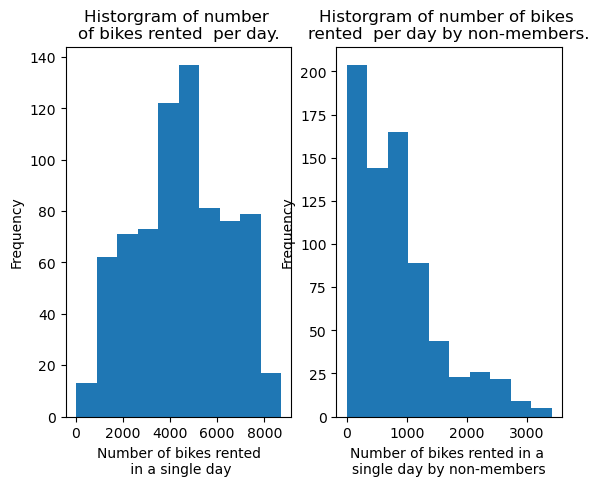

In [80]:
#Ploting the distruibutions
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2)

#Count
axes[0].hist(data_days["cnt"]);
axes[0].set_title("Historgram of number \nof bikes rented  per day.")
axes[0].set_xlabel("Number of bikes rented\n in a single day")
axes[0].set_ylabel("Frequency")

#Casual
axes[1].hist(data_days["casual"]);
axes[1].set_title("Historgram of number of bikes \nrented  per day by non-members.");
axes[1].set_xlabel("Number of bikes rented in a \nsingle day by non-members")
axes[1].set_ylabel("Frequency")

When compared with total bikes rented per day, bikes rented by non members is clearly skewed. To visyualize outliers, we create a boxplot of these two variables.

Text(0.5, 1.0, 'Number of bikes rented in a\n  single day by non-members')

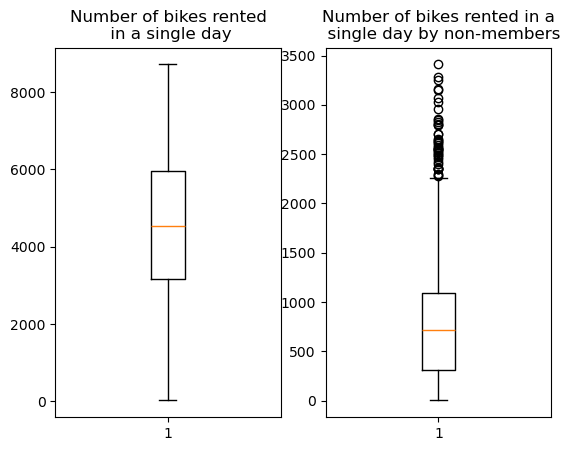

In [85]:
fig, axes = plt.subplots(1, 2)

#boxplot for cnt
axes[0].boxplot(data_days["cnt"]);
axes[0].set_title("Number of bikes rented\n in a single day")

#boxplot for casual
axes[1].boxplot(data_days["casual"]);
axes[1].set_title("Number of bikes rented in a\n  single day by non-members")



In [100]:
q1 = data_days["casual"].quantile(0.25)
q3 = data_days["casual"].quantile(0.75)
iqr = q3-q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

outliers = (data_days["casual"] < lower_bound ) | (data_days["casual"] > upper_bound)
data_days[outliers]
outliers.sum()

np.int64(44)

In [129]:
remaining_num_values = (~data_days[numerical_var].isin(data_days[["casual", "cnt"]])).columns

remaining_num_values = numerical_var[~numerical_var.isin(["casual", "cnt"])]
print(remaining_num_values)


Index(['temp', 'atemp', 'hum', 'windspeed', 'registered'], dtype='object')


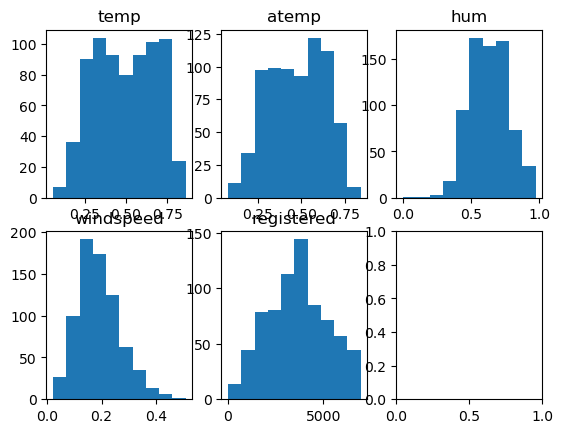

In [131]:
fig, axes = plt.subplots(2, 3)
current = 0
for i in remaining_num_values:
    axes.flat[current].hist(data_days[i])
    axes.flat[current].set_title(i)
    current += 1


In [133]:
data_days[numerical_var].corr()

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.991702,0.126963,-0.157944,0.543285,0.540012,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,0.543864,0.544192,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,-0.077008,-0.091089,-0.100659
windspeed,-0.157944,-0.183643,-0.248489,1.000000,-0.167613,-0.217449,-0.234545
casual,0.543285,0.543864,-0.077008,-0.167613,1.000000,0.395282,0.672804
registered,0.540012,0.544192,-0.091089,-0.217449,0.395282,1.000000,0.945517
cnt,0.627494,0.631066,-0.100659,-0.234545,0.672804,0.945517,1.000000


<Axes: >

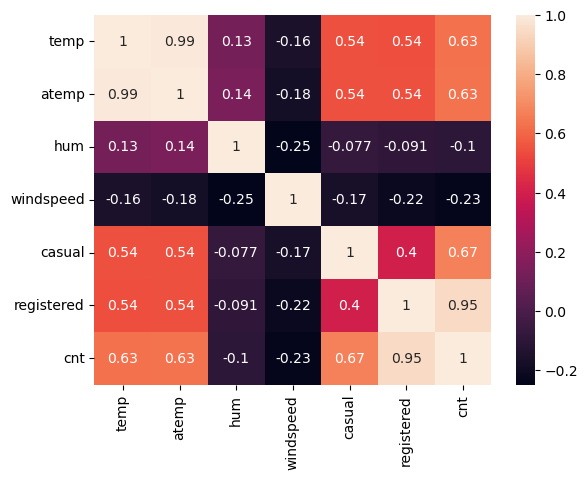

In [134]:
import seaborn as sns

sns.heatmap(data_days[numerical_var].corr(), annot=True)